# TP1: Methodes de gradient pour l’optimisation sans contrainte
## 12/05/2026
#### Léo SENTES Mia PERROUIN

### Exercice 1. Minimisation d’une forme lineaire quadratique par méthodes de gradients

On cherche à minimiser sur $R^2$ la forme quadratique donnée par :

$ f_1(x,y) = x^2 + y^2 -xy -x - y$

#### 1.

On veut prouver que $f_1$ admet un unique minimum global sur $R^2$ lorsque $x^*= (1,1)^T $

On commence par calculer $\nabla{f_1}=\begin{bmatrix}
 2x-y-1 \\
 2y-x-1
\end{bmatrix}$

Donc le vecteur $(1,1)^T $ est une solution.

Pour prouver son unicité, on calcule la matrice hessienne de $f_1$ et ses valeurs propres afin de montrer leur positivité, ce qui engendrera la convexité stricte de $f_1$ on a:
$\nabla{f_1}^2=\begin{bmatrix}
 2 & -1 \\
-1 & 2
\end{bmatrix}$
et de valeurs propres: $(1,3)$.

Comme $f_1$ est strictement convexe, alors d'après le cours il y a au plus un minimum global de $f_1$ sur $R^2$ qui est $x^*= (1,1)^T $


#### 2.

On developpe le système linéaire $Ax=b$:
On s'aperçoit qu'en développant, nous retombons sur 
 $\nabla{f_1}=\begin{bmatrix}
 2x-y-1 \\
 2y-x-1
\end{bmatrix}=\begin{bmatrix} 0 \\ 0 \end{bmatrix}$

Qui a pour solution $x^*= (1,1)^T $.

#### 3.

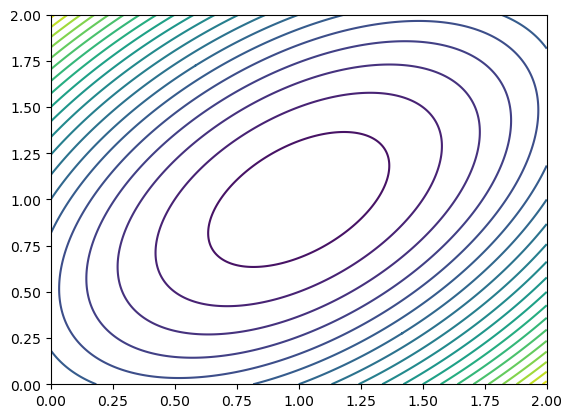

In [6]:
import numpy as np
import matplotlib.pyplot as plt
def f (x,y):
    return(x**2+y**2-x*y-x-y)

x=np.linspace(0,2,5000)
y=np.linspace(0,2,5000)
x2,y2=np.meshgrid(x,y)
z=f(x2,y2)
plt.contour(x2,y2,z,20)
plt.show()

#### 4.

In [89]:
A=np.array([[2,-1],[-1,2]])
b= np.array([1,1])

In [90]:
def gradf1(x):
    return(np.dot(A,x) - b)
x=np.array([1,1])
print(gradf1(x))

[0 0]


#### 5.
a.

In [91]:
def gradientpasfixe ( x0 , gradf , beta , valeps ):
    xk=x0
    i=0
    while (np.linalg.norm(gradf(xk)) > valeps) and (i<500) :
        i+=1
        xk= xk - beta * gradf(xk)
    return(xk,i)

Nous avons utliser le web afin d'obtenir une fonction calculant la norme euclidienne d'un vecteur.

b.

Afin que la méthode converge il faut que $\beta$, notre pas, $\beta \in [0,\frac{2}{M}]$ avec $M$ la plus grander valeur propre de A, ici $M=3$.

c.

Afin d'obtenir $\beta$ optimal, qui correspond à la vitesse de convergence maximale, on le calcule $\beta_{opt} = \frac{2}{M+N}$ avec $N$ la plus petit valeur propre de A, ici 1.

$\beta_{opt} = 0.5$

d.

In [92]:
x0 = np.array([[0.2],[1.0]])
print(gradientpasfixe(x0,gradf1,0.1,10**(-5)))
x0 = np.array([[0.2],[1.0]])
print(gradientpasfixe(x0,gradf1,0.5,10**(-5)))
x0 = np.array([[0.2],[1.0]])
print(gradientpasfixe(x0,gradf1,0.67,10**(-5)))

(array([[0.99999543, 0.99999543],
       [0.99999543, 0.99999543]]), 108)
(array([[0.99999695, 0.99999695],
       [1.        , 1.        ]]), 18)
(array([[-56.90910897, -56.90910897],
       [ 58.90910897,  58.90910897]]), 500)


Nous avons effectué 3 tests:

Le premier qui converge lentement (104 itérations)

Le second qui est optimal (18 itérations)

Le troisième qui ne converge pas (on atteint la condition d'arret)

In [96]:
def gradientpasfixe2 ( x0 , gradf , beta , valeps ):
    xk=x0
    tab_x=[x0[0]]
    tab_y=[x0[1]]
    i=0
    while np.linalg.norm(gradf(xk)) > valeps and i<500 :
        xk=xk - beta * gradf(xk)
        tab_x.append(xk[0])
        tab_y.append(xk[1])
        i+=1
    return tab_x, tab_y

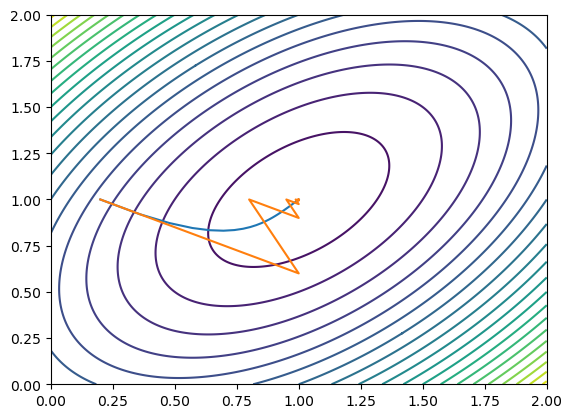

In [104]:
x=np.linspace(0,2,5000)
y=np.linspace(0,2,5000)
x2,y2=np.meshgrid(x,y)
z=f(x2,y2)
plt.contour(x2,y2,z,20)
vx,vy=gradientpasfixe2([0.2,1],gradf1,0.1,0.00001)
plt.plot(vx,vy)
wx,wy=gradientpasfixe2([0.2,1],gradf1,0.5,0.00001)
plt.plot(wx,wy)
ux,uy=gradientpasfixe2([0.2,1],gradf1,0.67,0.00001)
#plt.plot(ux,uy)
plt.show()

#### 6.

In [102]:
def gradientpaslocaloptimal ( x0 , gradf ,A , valeps ):
    xk=x0
    i=0
    while np.linalg.norm(gradf(xk)) > valeps and i<500 :
        beta_k = np.linalg.norm(gradf(xk)**2/(np.dot(np.dot(A,gradf(xk)),gradf(xk))))
        xk= xk - beta_k * gradf(xk)
        i+=1
    return xk,i

In [103]:
def gradientpaslocaloptimal2 ( x0 , gradf ,A , valeps ):
    xk=x0
    tab_x=[x0[0]]
    tab_y=[x0[1]]
    i=0
    while np.linalg.norm(gradf(xk)) > valeps and i<500 :
        beta_k = np.linalg.norm(gradf(xk)**2/(np.dot(np.dot(A,gradf(xk)),gradf(xk))))
        xk= xk - beta_k * gradf(xk)
        tab_x.append(xk[0])
        tab_y.append(xk[1])
        i+=1
    return tab_x, tab_y

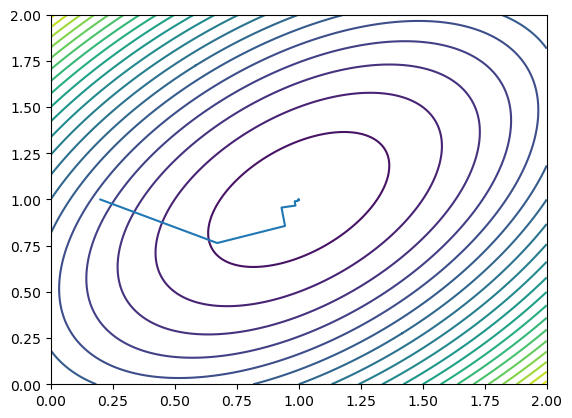

In [105]:
x=np.linspace(0,2,5000)
y=np.linspace(0,2,5000)
x2,y2=np.meshgrid(x,y)
z=f(x2,y2)
plt.contour(x2,y2,z,20)
A=np.array([[2,-1],[-1,2]])
vx,vy=gradientpaslocaloptimal2([0.2,1],gradf1,A,0.00001)
plt.plot(vx,vy)
plt.show()

### Exercice 2.  Minimisation d’une forme lineaire non quadratique

On cherche à minimiser sur $R^2$ la forme quadratique donnée par :
2$
$2f_1(x,y( -1)= x^210(x+ y^ )^2- y$

#### 1.

On veut prouver que 2f_1$ admet un unique minimum global sur $R^2$ lorsque $x^*= (1,1)^T $

On commence par calculer $\nabla{f_1}=\begin{bmatrix(}(
 1) + 40x(x^2- 2)y-1 \-\0(x^2 y)x-1
\end{bmatrix}$

Donc le vecteur $(1,1)^T $ est une solutin.


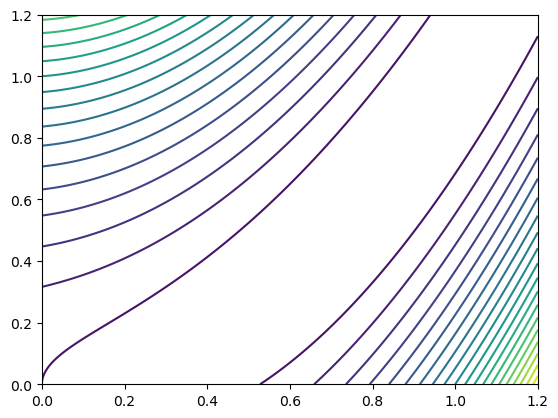

In [107]:
def f2 (x,y):
    return((x-1)**2 + 10*(x**2 - y)**2)

x=np.linspace(0,1.2,5000)
y=np.linspace(0,1.2,5000)
x2,y2=np.meshgrid(x,y)
z=f2(x2,y2)
plt.contour(x2,y2,z,20)
plt.show()

In [112]:
def gradf2(x,y):
    return(2*(x-1) + 40*x*(x^2- y),20*(y-x^2))

def gradientpasfixe3 ( x0 , gradf , beta , valeps ):
    xk=x0
    i=0
    while (np.linalg.norm(gradf(xk,yk)) > valeps) and (i<500) :
        i+=1
        xk= xk - beta * gradf(xk)[0]
    return(xk,yk,i)

TypeError: gradf2() missing 1 required positional argument: 'y'

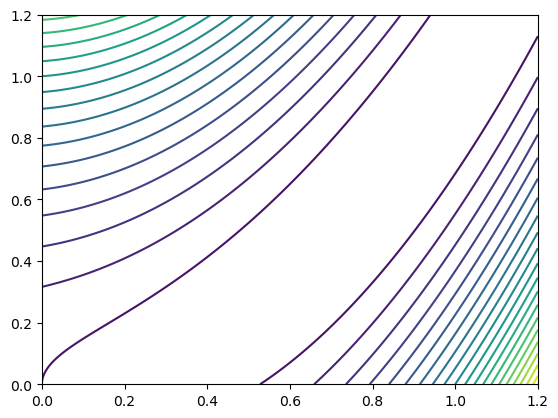

In [111]:
x=np.linspace(0,1.2,5000)
y=np.linspace(0,1.2,5000)
x2,y2=np.meshgrid(x,y)
z=f2(x2,y2)
plt.contour(x2,y2,z,20)
vx,vy=gradientpasfixe2([0.2,0.8],gradf2,0.01,0.00001)
plt.plot(vx,vy)